# Course NIGK21007U - Integrated Water Resources Modelling
## Term Project Session 1

This notebook provides some inspiration and sample code to work with the tasks in Term Project Session 1

### <span style="color: red;"> 2a Download and visualize ESA CCI soil moisture</span>

First, import all necessary modules:

In [1]:
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import re 
import sys
import geopandas as gpd
from shapely.geometry import Point
from shapely.geometry import box
from matplotlib.colors import Normalize
import xarray as xr
import datetime
from pyresample.geometry import AreaDefinition

Provide the path and name of the file you downloaded from the ESA archive:

In [2]:
file_path = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Term_project_sessions\Session_1\ESACCI-SOILMOISTURE-L3S-SSMV-COMBINED-20240627000000-fv09.2.nc'

Define a geographic bounding box for the Denmark domain:

In [3]:
DENMARK_LAT_MIN = 54.0
DENMARK_LAT_MAX = 58.0
DENMARK_LON_MIN = 8.0
DENMARK_LON_MAX = 14.0

Load the data and coordinates from the file:

In [4]:
with netCDF4.Dataset(file_path, 'r') as nc_f:
        # --- 2. Load Coordinates ---
        lats = nc_f.variables['lat'][:]
        lons = nc_f.variables['lon'][:]

        # --- 3. Calculate Index Subset for Denmark ---
        # Find the indices corresponding to the bounds
        lat_idx = np.where((lats >= DENMARK_LAT_MIN) & (lats <= DENMARK_LAT_MAX))[0]
        lon_idx = np.where((lons >= DENMARK_LON_MIN) & (lons <= DENMARK_LON_MAX))[0]

        # Get the slice indices
        lat_start = lat_idx.min()
        lat_end = lat_idx.max() + 1
        lon_start = lon_idx.min()
        lon_end = lon_idx.max() + 1

        # --- 4. Load Data Subset ---
        # Note: SM data often has a shape (time, lat, lon) or (lat, lon)
        # Assuming (time, lat, lon) and selecting the first time step [0]
        sm_data = nc_f.variables['sm'][0, lat_start:lat_end, lon_start:lon_end]
        
        # Load the cropped coordinates
        plot_lats = lats[lat_start:lat_end]
        plot_lons = lons[lon_start:lon_end]

        # Get time for title (assuming it's available)
        try:
            time_var = nc_f.variables['time']
            date_units = time_var.units
            date_calendar = time_var.calendar if 'calendar' in time_var.ncattrs() else 'standard'
            date_value = netCDF4.num2date(time_var[0], units=date_units, calendar=date_calendar)
            date_str = date_value.strftime('%Y-%m-%d')
        except Exception:
            date_str = "Unknown Date"

Plot the data with cartopy:

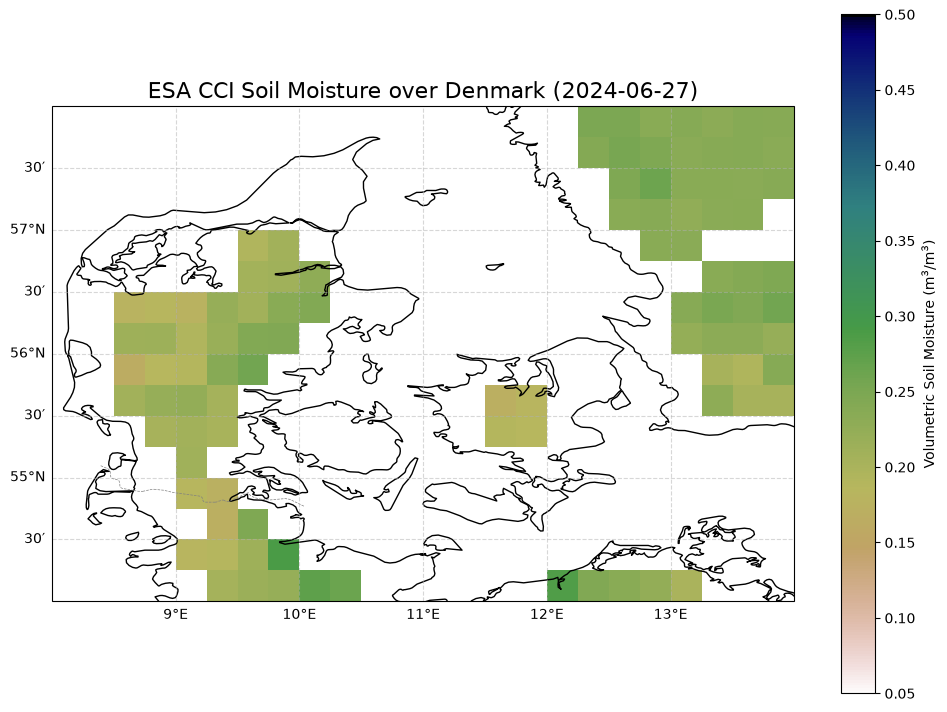

In [5]:
# Create a meshgrid for pcolormesh
lon_grid, lat_grid = np.meshgrid(plot_lons, plot_lats)

fig = plt.figure(figsize=(10, 10))
# Use PlateCarree for data projection (standard lat/lon grid)
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Create the color plot
im = ax.pcolormesh(
    lon_grid, lat_grid, sm_data,
    transform=ccrs.PlateCarree(),
    vmin=0.05, # Volumetric Soil Moisture (m³/m³)
    vmax=0.50, 
    cmap='gist_earth_r', 
)

# Add features for context
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='gray', linewidth=0.5)

# Add color bar
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label(r'Volumetric Soil Moisture ($\mathrm{m}^3 / \mathrm{m}^3$)')

# Set the plot extent
ax.set_extent([DENMARK_LON_MIN, DENMARK_LON_MAX, DENMARK_LAT_MIN, DENMARK_LAT_MAX],
                crs=ccrs.PlateCarree())

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                    linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Title
plt.title(f'ESA CCI Soil Moisture over Denmark ({date_str})', fontsize=16)
plt.tight_layout()
plt.show()

# Save the figure for reporting, if needed

# plt.savefig('soil_moisture_denmark.png', dpi=300)

### <span style="color: red;"> 2b Download and visualize MOD16 actual ET</span>

Define the file name and the datasets you want to extract:

In [6]:
file_path = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Term_project_sessions\Session_1\MOD16A2.A2025185.h18v03.061.2025220031146.hdf'
SDS_NAME = 'ET_500m'
QC_NAME = 'ET_QC_500m'

Define 2 utility functions to (1) find the corner coordinates of the MODIS tile and (2) mask no-data and low quality (QC >150) areas:

In [7]:
def parse_modis_coords(metadata_str):
    """Parses UpperLeftPointMtrs and LowerRightMtrs from the StructMetadata.0 string."""
    
    # Simple regex to match the exact keys
    ul_match = re.search(r'UpperLeftPointMtrs=\((.*?)\)', metadata_str)
    lr_match = re.search(r'LowerRightMtrs=\((.*?)\)', metadata_str)
    
    if not ul_match or not lr_match:
        raise ValueError("Could not find UpperLeftPointMtrs or LowerRightMtrs in metadata.")
        
    ul_coords = tuple(map(float, ul_match.group(1).split(',')))
    lr_coords = tuple(map(float, lr_match.group(1).split(',')))
    
    # Extracting and assigning to standard variables
    min_x = ul_coords[0]
    max_y = ul_coords[1]
    max_x = lr_coords[0]
    min_y = lr_coords[1]
    
    # Returns min_x, max_x, min_y, max_y (pyresample's expected order for the extent tuple)
    return min_x, max_x, min_y, max_y 

def create_combined_mask(nc_f, et_data, qc_data, fill_value, scale_factor, qc_threshold=150):
    """Creates a combined mask for fill values and low quality data (QC > 150)."""
    
    fill_mask = et_data == fill_value
    qc_mask = (qc_data > qc_threshold) | (qc_data == 255) | (qc_data == 127)
    combined_mask = fill_mask | qc_mask
    return np.ma.masked_where(combined_mask, et_data * scale_factor)

Read and subset the data:

In [8]:
with netCDF4.Dataset(file_path, 'r') as nc_f:
    
    # --- File Inspection & Data Loading ---
    print("--- Attempting Lat/Lon Plot using pyresample V2 ---")
    print(f"Loading variables: {SDS_NAME} and {QC_NAME}")
    print("\n--- Available Variables (SDS Names) in the HDF file ---")
    print(f"File Path: {file_path}")
    print(list(nc_f.variables.keys()))
    print("----------------------------------------------------------\n")
    
    # ... (File Inspection and Loading) ...
    
    # --- NEW INSPECTION BLOCK ---
    print("\n--- Variable Metadata Inspection (ET_500m) ---")
    var_et = nc_f.variables[SDS_NAME]
    
    # Check and print the scale factor
    if hasattr(var_et, 'scale_factor'):
        file_scale_factor = var_et.scale_factor
        print(f"Scale Factor found in file: {file_scale_factor}")
    else:
        file_scale_factor = 0.1 # Default if not found
        print("Scale Factor not explicitly found in variable attributes. Using default 0.1.")
        
    # Check and print the offset (should be 0)
    if hasattr(var_et, 'add_offset'):
        file_add_offset = var_et.add_offset
        print(f"Add Offset found in file: {file_add_offset}")
    else:
        file_add_offset = 0.0
        print("Add Offset not found. Using default 0.0.")

    # Check and print the units
    if hasattr(var_et, 'units'):
        file_units = var_et.units
        print(f"Units found in file: {file_units}")
    else:
        file_units = "kg/m^2/8days"
        print("Units not found. Using default kg/m^2/8days.")
    
    print("----------------------------------------------------------")

    # Load data
    et_data = nc_f.variables[SDS_NAME][:, :] 
    qc_data = nc_f.variables[QC_NAME][:, :]
    fill_value = nc_f.variables[SDS_NAME]._FillValue
    scale_factor = 0.1
    
    et_masked = create_combined_mask(nc_f, et_data, qc_data, fill_value, scale_factor, qc_threshold=150)

    # --- 3. Determine Coordinates and Projection (pyresample FIX) ---
    metadata_str = nc_f.getncattr('StructMetadata.0')
    print("Parsing StructMetadata string for coordinates...")

    min_x, max_x, min_y, max_y = parse_modis_coords(metadata_str)
    print(f"Extracted Coordinates (m): X: {min_x} to {max_x}, Y: {min_y} to {max_y}")

    n_rows, n_cols = et_masked.shape
    
    # 1. Define the MODIS Sinusoidal Area using pyresample
    proj_dict = {
        'proj': 'sinu', 
        'a': '6371007.181', 
        'b': '6371007.181', 
        'units': 'm', 
    }
    
    # The coordinates must be passed as (min_x, min_y, max_x, max_y) for pyresample extent:
    area_extent = (min_x, min_y, max_x, max_y)
    
    # Create the AreaDefinition object
    modis_area = AreaDefinition(
        'modis_area', 'MODIS Sinusoidal Tile', 'MODIS_SINU',
        proj_dict, n_cols, n_rows, area_extent
    )
    
    # 2. Extract Lat/Lon Grid from the defined Area
    lons, lats = modis_area.get_lonlats()
    
    
    # --- SUBSETTING FIX: Filter the data to only include the target region ---
    
    lon_mask = (lons >= DENMARK_LON_MIN) & (lons <= DENMARK_LON_MAX)
    lat_mask = (lats >= DENMARK_LAT_MIN) & (lats <= DENMARK_LAT_MAX)
    
    denmark_mask = lon_mask & lat_mask
    
    if not np.any(denmark_mask):
        print("\nError: No data cells found within the defined Denmark bounds after projection.")
        print("The pyresample alignment failed. Please verify pyresample's dependencies are installed (e.g., cartopy, proj).")
        sys.exit() 

    # Subsetting data based on mask
    rows, cols = np.where(denmark_mask)
    row_min, row_max = rows.min(), rows.max() + 1
    col_min, col_max = cols.min(), cols.max() + 1
    
    et_denmark = et_masked[row_min:row_max, col_min:col_max]
    lons_denmark = lons[row_min:row_max, col_min:col_max]
    lats_denmark = lats[row_min:row_max, col_min:col_max]

--- Attempting Lat/Lon Plot using pyresample V2 ---
Loading variables: ET_500m and ET_QC_500m

--- Available Variables (SDS Names) in the HDF file ---
File Path: h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Term_project_sessions\Session_1\MOD16A2.A2025185.h18v03.061.2025220031146.hdf
['ET_500m', 'LE_500m', 'PET_500m', 'PLE_500m', 'ET_QC_500m']
----------------------------------------------------------


--- Variable Metadata Inspection (ET_500m) ---
Scale Factor found in file: 0.1
Add Offset found in file: 0.0
Units found in file: kg/m^2/8day
----------------------------------------------------------
Parsing StructMetadata string for coordinates...
Extracted Coordinates (m): X: 0.0 to 1111950.519667, Y: 5559752.598333 to 6671703.118


Plotting with cartopy:

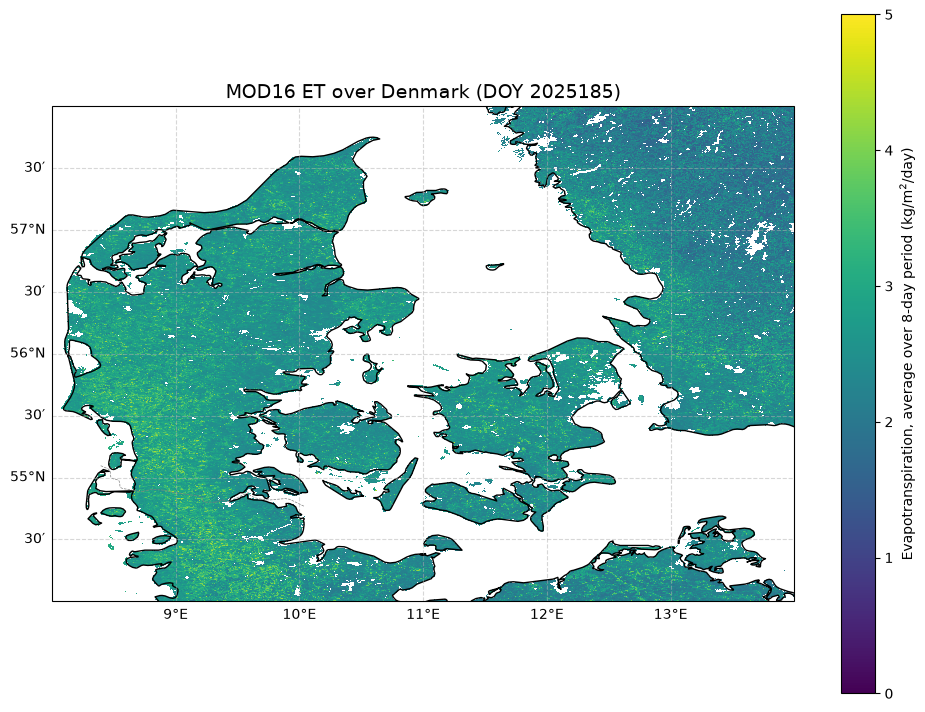

In [9]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Plotting the subsetted data using Lat/Lon coordinates
im = ax.pcolormesh(
    lons_denmark, lats_denmark, et_denmark,  
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    vmin=0,
    vmax=5,
)

# This tells Cartopy to only process geometry within these bounds.
ax.set_extent([DENMARK_LON_MIN, DENMARK_LON_MAX, DENMARK_LAT_MIN, DENMARK_LAT_MAX],
                crs=ccrs.PlateCarree())
# Add map features
ax.coastlines(resolution='10m', color='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='gray', linewidth=0.5)

# Add color bar and title
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label(r'Evapotranspiration, average over 8-day period ($\mathrm{kg} / \mathrm{m}^2 /\mathrm{day}$)')

ax.set_extent([DENMARK_LON_MIN, DENMARK_LON_MAX, DENMARK_LAT_MIN, DENMARK_LAT_MAX],
                crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False

date_str = file_path.split('.')[1][1:] 
plt.title(f'MOD16 ET over Denmark (DOY {date_str})', fontsize=14)

plt.tight_layout()
plt.savefig('MOD16_ET_latlon_pyresample_plot.png', dpi=300)
plt.show()

Note that MOD16 actual ET is given in units of $kg/m^2/day$, which is equivalent to $mm/day$.

### <span style="color: red;"> 2c Download and visualize SWOT PIXC data</span>

First, give the path and name of the SWOT PIXC file you downloaded and the river shapefile for your domain:

In [10]:
# SWOT PIXC NetCDF file
PIXC_NC_FILE = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Term_project_sessions\Session_1\SWOT_L2_HR_PIXC_042_335_253R_20251204T152724_20251204T152735_PID0_01.nc'
# Sjælland River Shapes file
RIVER_SHP_FILE = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Term_project_sessions\Session_1\Rivers_Sjaelland.shp'

Define the domain bounds:

In [11]:
# Approximate geographical bounds for DK1 domain
DK1_LAT_MIN = 55
DK1_LAT_MAX = 56
DK1_LON_MIN = 11
DK1_LON_MAX = 12.5

Define the target variable in the SWOT PIXC file:

In [12]:
# A. Load SWOT PIXC Points from NetCDF
TARGET_GROUP = 'pixel_cloud' # <-- NEW: Specify the group where data lives
WSE_VARIABLE = 'height'      # <-- NEW: Use 'height' as the water surface elevation variable

Read the SWOT data:

In [13]:
with netCDF4.Dataset(PIXC_NC_FILE, 'r') as nc_f:
    # Access the target group
    data_group = nc_f.groups[TARGET_GROUP] 
    
    # Read key variables from the group
    lon = data_group.variables['longitude'][:]
    lat = data_group.variables['latitude'][:]
    wse = data_group.variables[WSE_VARIABLE][:] # Use 'height'
    
    # Simple quality filter: remove fill values and NaNs
    # SWOT PIXC files often use a very large negative number for fill values.
    # Check against a sensible minimum value (e.g., -500 meters)
    valid_mask = (wse > -500) & (np.isfinite(wse)) 
    
    lon_v = lon[valid_mask]
    lat_v = lat[valid_mask]
    wse_v = wse[valid_mask]

    if lon_v.size == 0:
        raise ValueError("No valid PIXC data points found after filtering.")

    # Create GeoDataFrame
    geometry = [Point(xy) for xy in zip(lon_v, lat_v)]
    pixc_gdf = gpd.GeoDataFrame({
        'geometry': geometry,
        'wse': wse_v # Renaming 'height' to 'wse' for plotting logic consistency
    }, crs=4326) # WGS84 CRS

Read the river shape file:

In [14]:
river_gdf = gpd.read_file(RIVER_SHP_FILE)
river_gdf = river_gdf.to_crs(epsg=4326)

Clip PIXC data to the relevant area for faster plotting:

In [15]:
clip_box = box(DENMARK_LON_MIN, DENMARK_LAT_MIN, 
               DENMARK_LON_MAX, DENMARK_LAT_MAX)
pixc_clipped = pixc_gdf.clip(clip_box)
print(f"Loaded {len(pixc_gdf)} PIXC points. Clipped to {len(pixc_clipped)} points for plotting.")

Loaded 7812716 PIXC points. Clipped to 7812716 points for plotting.


Plotting with cartopy:

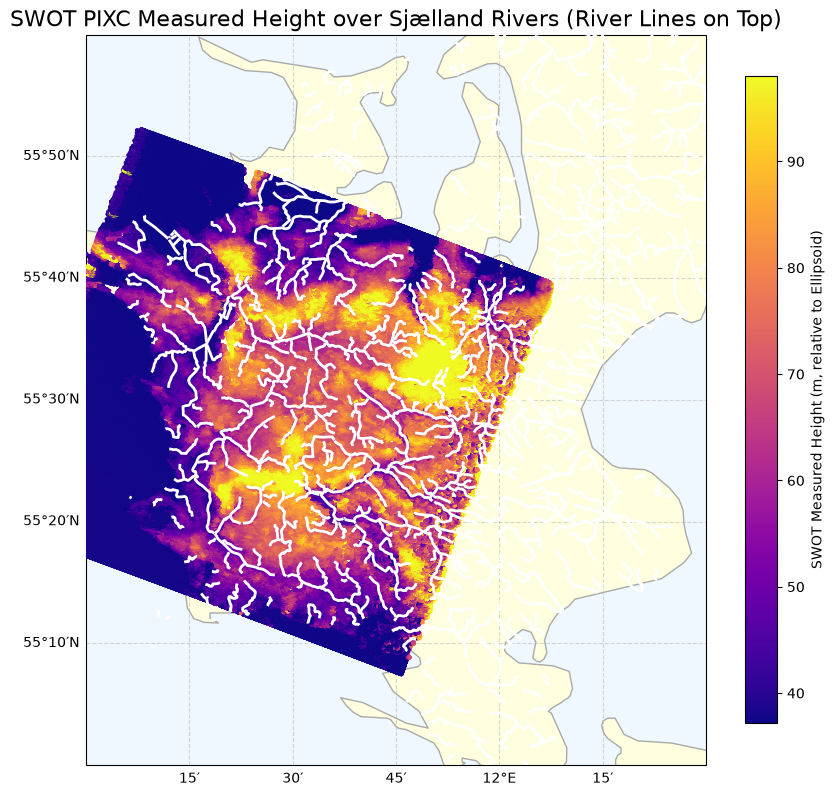

In [16]:
fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# A. Set Map Extent and Features
BUFFER = 0.
ax.set_extent([DK1_LON_MIN - BUFFER, DK1_LON_MAX + BUFFER, 
               DK1_LAT_MIN - BUFFER, DK1_LAT_MAX + BUFFER],
              crs=ccrs.PlateCarree())

ax.coastlines(resolution='10m', color='darkgray', linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='gray', linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor='lightyellow', edgecolor='none', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', edgecolor='none', zorder=0)

# B. Plot River Shapes  - Line-only and Top Layer (zorder=4)
river_gdf.plot(
    ax=ax, 
    edgecolor='white', 
    facecolor='none',  # <-- CHANGE: Set facecolor to 'none' for line-only
    linewidth=2.0,     # <-- CHANGE: Increase linewidth for visibility
    alpha=1.0,         # <-- CHANGE: Ensure it's fully opaque
    zorder=4,          # <-- CHANGE: Set zorder higher than points (zorder=3)
    transform=ccrs.PlateCarree()
)

# C. Plot SWOT PIXC Points (WSE) - Points are underneath the river line (zorder=3)
if not pixc_clipped.empty:
    
    wse_values = pixc_clipped['wse'].values
    vmin = np.nanpercentile(wse_values, 5) if wse_values.size > 0 else None
    vmax = np.nanpercentile(wse_values, 95) if wse_values.size > 0 else None
    
    scatter = ax.scatter(
        pixc_clipped.geometry.x,
        pixc_clipped.geometry.y,
        c=wse_values,
        s=8, 
        marker='o',
        cmap='plasma', 
        norm=Normalize(vmin=vmin, vmax=vmax) if vmin is not None else None,
        transform=ccrs.PlateCarree(),
        edgecolors='none', 
        zorder=3 # <-- Ensure this is less than the river zorder (4)
    )

    swot_cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', pad=0.05, shrink=0.7)
    swot_cbar.set_label('SWOT Measured Height (m, relative to Ellipsoid)')
    
# D. Final Formatting 
plt.title('SWOT PIXC Measured Height over Sjælland Rivers (River Lines on Top)', fontsize=16)

gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                  linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

plt.show()

### <span style="color: red;"> 2e Download and visualize GRAVIS TWS data</span>

Provide path and name of the file you downloaded:

In [17]:
TWS_NC_FILE = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Term_project_sessions\Session_1\GRAVIS-3_GFZOP_0600_TWS_GRID_GFZ_0006.nc' # <-- UPDATE THIS PATH

Define target dates:

In [18]:
# Target Dates (for indexing into the monthly time series)
TARGET_DATES = {
    "Summer/Dry (Aug 2022)": datetime.datetime(2022, 8, 1),
    "Winter/Wet (Mar 2024)": datetime.datetime(2024, 3, 1)
}

Define the variable name to be plotted:

In [19]:
VAR_NAME = 'tws' # Terrestrial Water Storage Anomaly (cm)

Loading the data from file:

In [20]:
# Open the dataset using xarray
ds = xr.open_dataset(TWS_NC_FILE)

# 2.1. Prepare the data for plotting

# Ensure the main variable is present
if VAR_NAME not in ds.data_vars:
    raise ValueError(f"Variable '{VAR_NAME}' not found in the NetCDF file.")
    
# Convert TWS to numpy array (time, lat, lon)
tws_data = ds[VAR_NAME]

# Create an empty list to store the extracted data slices
extracted_data = {}

for label, target_date in TARGET_DATES.items():
    print(f"Extracting data for: {label} ({target_date.strftime('%Y-%m')})")
    
    # Select the nearest time step to the target date
    # Note: 'nearest' is used because monthly data is often stamped at the middle of the month
    data_slice = tws_data.sel(time=target_date, method='nearest')
    
    # Clip the data spatially to the Denmark bounds
    # Xarray's .sel method handles gridded slicing cleanly
    data_clipped = data_slice.sel(
        lat=slice(DENMARK_LAT_MAX, DENMARK_LAT_MIN),
        lon=slice(DENMARK_LON_MIN, DENMARK_LON_MAX)
    )
    
    # Store the clipped data array
    extracted_data[label] = data_clipped
    
# Extract clipped coordinates (used for both plots)
plot_lats = extracted_data[list(extracted_data.keys())[0]].lat.values
plot_lons = extracted_data[list(extracted_data.keys())[0]].lon.values

Extracting data for: Summer/Dry (Aug 2022) (2022-08)
Extracting data for: Winter/Wet (Mar 2024) (2024-03)


Plotting with cartopy:

C:\Users\vpk410\AppData\Local\Temp\ipykernel_4176\680276759.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the colorbar


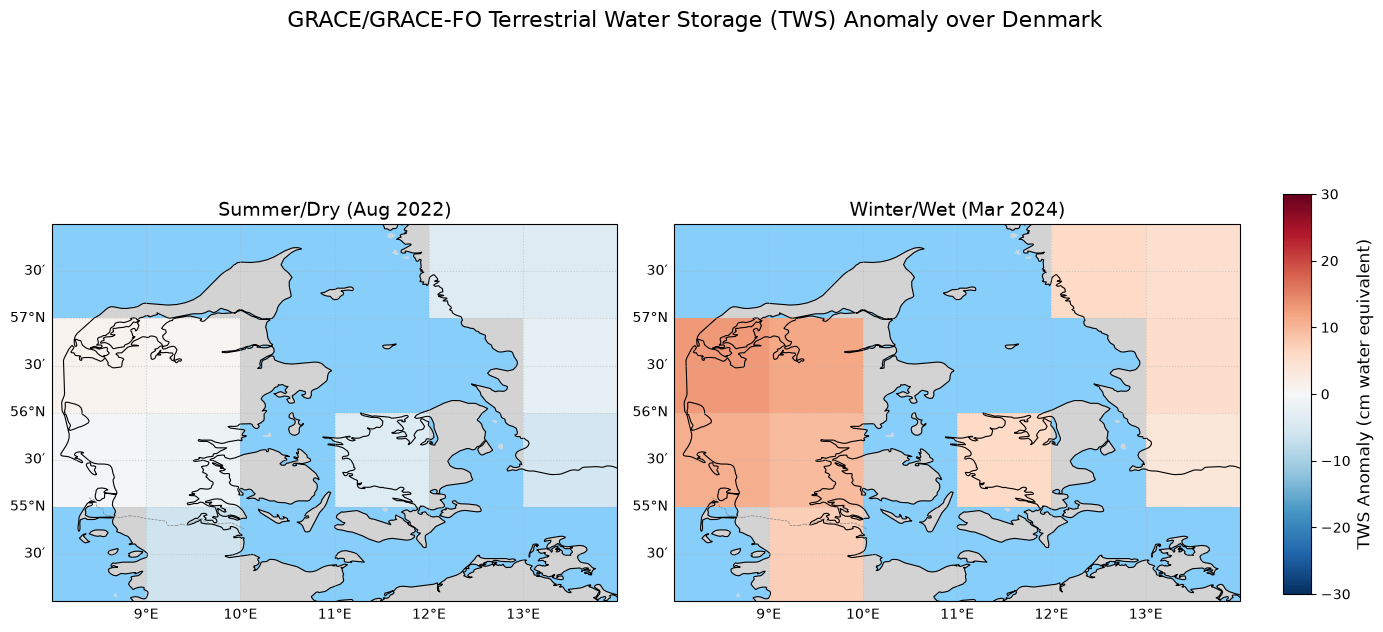

In [21]:
# Determine a common color range (e.g., +/- 30 cm)
VMAX = 30.0
VMIN = -VMAX 

fig, axes = plt.subplots(
    nrows=1, ncols=len(extracted_data), 
    figsize=(14, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
fig.suptitle('GRACE/GRACE-FO Terrestrial Water Storage (TWS) Anomaly over Denmark', fontsize=16)

# Use np.meshgrid for pcolormesh
lon_grid, lat_grid = np.meshgrid(plot_lons, plot_lats)

# Loop through the extracted data and plot each month
for i, (label, tws_array) in enumerate(extracted_data.items()):
    
    ax = axes[i]
    
    # Plot the TWS data using pcolormesh
    im = ax.pcolormesh(
        lon_grid, lat_grid, tws_array.values,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r', # Red-Blue reversed (Blue for high water, Red for low water)
        vmin=VMIN,
        vmax=VMAX
    )
    
    # Set the map extent (slightly buffered)
    BUFFER = 0.0
    ax.set_extent([DENMARK_LON_MIN - BUFFER, DENMARK_LON_MAX + BUFFER, 
                   DENMARK_LAT_MIN - BUFFER, DENMARK_LAT_MAX + BUFFER],
                  crs=ccrs.PlateCarree())
    
    # Add features for context
    ax.coastlines(resolution='10m', color='black', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='--', edgecolor='gray', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='lightskyblue', edgecolor='none')
    
    # Add gridlines and labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      linestyle=':', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    
    ax.set_title(label, fontsize=14)

# --- 4. Finalizing and Colorbar ---

# Add a single color bar for both plots
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5]) # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.set_label('TWS Anomaly (cm water equivalent)', fontsize=12)

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Adjust layout to make space for the colorbar
plt.show()